## Caso práctico: EDA de ventas de una cadena retail

La empresa **RetailNova Perú** comercializa productos tecnológicos y accesorios a través de cuatro tiendas:
- Lima
- Arequipa
- Trujillo
- Cusco

La gerencia ha entregado al área de análisis de datos un archivo con las ventas de los últimos seis meses. El problema es que la gerencia tiene los datos, pero no sabe exactamente:

- qué sucursal tiene mejor desempeño;
- qué productos generan mayores ingresos;
- si los descuentos están ayudando a vender más;
- qué métodos de pago utilizan los clientes;
- si existen datos incorrectos o anomalías;
- qué factores están asociados con las devoluciones;
- qué conclusiones comerciales pueden obtenerse.

### Objetivo general

La gerencia de RetailNova solicita realizar un análisis exploratorio de sus operaciones comerciales con el objetivo de identificar patrones de ventas, comportamiento de clientes, desempeño de sucursales, posibles problemas de calidad de datos y oportunidades comerciales.

In [ ]:
# 1. Cargar librerias necesarias para el EDA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 2. Cargar datos de ventas
df_ventas = pd.read_csv("./data/ventas_retail.csv", encoding="utf-8")
df_ventas.head()

,id_venta,fecha,sucursal,vendedor,categoria,producto,cantidad,precio_unitario,descuento_pct,metodo_pago,tipo_cliente,edad_cliente,satisfaccion,tiempo_atencion_min,devolucion
0,V001,2026-01-05,Lima,V001,Laptops,Laptop Lenovo,1,2800.0,5,Tarjeta,Nuevo,32.0,5.0,12.0,No
1,V002,2026-01-05,Arequipa,V008,Accesorios,Mouse Logitech,3,90.0,0,Yape,Frecuente,28.0,NaN,8.0,No
2,V003,2026-01-06,Lima,V003,Monitores,Monitor Samsung,50,780.0,10,Tarjeta,Frecuente,NaN,3.0,18.0,No
3,V004,2026-01-06,Cusco,V012,Accesorios,Teclado Redragon,1,180.0,5,efectivo,NUEVO,NaN,4.0,10.0,No
4,V005,2026-01-07,Trujillo,V010,Laptops,Laptop HP,1,3100.0,15,Tarjeta,nuevo,NaN,2.0,35.0,Si


In [3]:
# 3. Obtener información general del dataset
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_venta             1005 non-null   str    
 1   fecha                1005 non-null   str    
 2   sucursal             1005 non-null   str    
 3   vendedor             1005 non-null   str    
 4   categoria            1005 non-null   str    
 5   producto             1005 non-null   str    
 6   cantidad             1005 non-null   int64  
 7   precio_unitario      1005 non-null   float64
 8   descuento_pct        1005 non-null   int64  
 9   metodo_pago          1005 non-null   str    
 10  tipo_cliente         1005 non-null   str    
 11  edad_cliente         924 non-null    float64
 12  satisfaccion         959 non-null    float64
 13  tiempo_atencion_min  977 non-null    float64
 14  devolucion           1005 non-null   str    
dtypes: float64(4), int64(2), str(9)
memory usage: 117

In [4]:
# 4. Análisis de valores nulos
df_ventas.isna().sum().sort_values(ascending = False)

edad_cliente           81
satisfaccion           46
tiempo_atencion_min    28
vendedor                0
id_venta                0
fecha                   0
sucursal                0
cantidad                0
producto                0
categoria               0
precio_unitario         0
tipo_cliente            0
metodo_pago             0
descuento_pct           0
devolucion              0
dtype: int64

In [5]:
# 5. Estadísticas descriptivas del dataset
df_ventas.describe()

,cantidad,precio_unitario,descuento_pct,edad_cliente,satisfaccion,tiempo_atencion_min
count,1005.000000,1005.000000,1005.000000,924.000000,959.000000,977.000000
mean,2.398010,1297.790209,8.890547,47.392857,3.312826,27.439099
std,6.481263,978.186296,12.727529,24.368567,1.285113,23.585835
min,1.000000,76.130000,0.000000,18.000000,1.000000,5.000000
25%,1.000000,656.980000,0.000000,32.000000,2.000000,14.000000
50%,1.000000,1086.160000,5.000000,44.500000,4.000000,25.000000
75%,2.000000,1777.150000,15.000000,59.000000,4.000000,36.000000
max,50.000000,3450.250000,70.000000,150.000000,5.000000,180.000000


Conclusiones de las estadísticas de datos númericos:
- Unidades vendidas mayores
- Descuentos exagerados
- Edad del cliente exagerada (no real)
- Demasiado tiempo de atención

In [20]:
# 6. Revisión de anomalías detectadas
# Unidades vendidas mayor a 20
df_anomalia_cantidad = df_ventas[df_ventas["cantidad"] > 20]
print("Unidades vendidas mayor a 20: ", df_anomalia_cantidad["cantidad"].count())
df_anomalia_cantidad.head()

Unidades vendidas mayor a 20:  18


,id_venta,fecha,sucursal,vendedor,categoria,producto,cantidad,precio_unitario,descuento_pct,metodo_pago,tipo_cliente,edad_cliente,satisfaccion,tiempo_atencion_min,devolucion
2,V003,2026-01-06,Lima,V003,Monitores,Monitor Samsung,50,780.00,10,Tarjeta,Frecuente,NaN,3.0,18.0,No
48,V049,2026-08-05,Cusco,V014,Monitores,Monitor ViewSonic,50,667.65,5,Transferencia,FRECUENTE,48.0,2.0,34.0,No
69,V070,2026-06-13,Cusco,V014,Laptops,Laptop Dell,50,3416.27,15,Yape,Frecuente,49.0,1.0,39.0,Si
107,V108,2026-06-27,cusco,V013,Accesorios,Mochila para laptop,50,118.58,0,Efectivo,Frecuente,34.0,4.0,8.0,No
134,V135,2026-06-28,Lima,V002,Laptops,Laptop Asus,50,2912.59,10,Efectivo,Nuevo,50.0,2.0,7.0,Si


In [21]:
# Descuentos mayores a 30%
df_anomalia_descuento = df_ventas[df_ventas["descuento_pct"] > 30]
print("Descuentos mayores a 30%: ", df_anomalia_descuento["descuento_pct"].count())
df_anomalia_descuento.head()

Descuentos mayores a 30%:  29


,id_venta,fecha,sucursal,vendedor,categoria,producto,cantidad,precio_unitario,descuento_pct,metodo_pago,tipo_cliente,edad_cliente,satisfaccion,tiempo_atencion_min,devolucion
5,V006,2026-06-17,Lima,V001,Accesorios,Teclado Redragon,3,175.02,70,Transferencia,Frecuente,NaN,3.0,18.0,No
10,V011,2026-08-29,Arequipa,V007,Laptops,Laptop HP,2,3199.76,70,Yape,Nuevo,54.0,3.0,25.0,No
18,V019,2026-02-07,CUSCO,V012,Smartphones,Smartphone Xiaomi,1,1162.85,70,yape,Frecuente,64.0,4.0,8.0,No
22,V023,2026-03-26,Lima,V001,TABLETS,Tablet Lenovo,2,1100.31,70,Tarjeta,VIP,29.0,4.0,9.0,No
153,V154,2026-05-05,Lima,V003,Smartphones,Smartphone Samsung,2,1848.41,70,Yape,VIP,42.0,2.0,29.0,No


In [22]:
# Clientes con edad mayor a 85
df_anomalia_edad = df_ventas[df_ventas["edad_cliente"] > 85]
print("Clientes con edad mayor a 85: ", df_anomalia_edad["edad_cliente"].count())
df_anomalia_edad.head()

Clientes con edad mayor a 85:  31


,id_venta,fecha,sucursal,vendedor,categoria,producto,cantidad,precio_unitario,descuento_pct,metodo_pago,tipo_cliente,edad_cliente,satisfaccion,tiempo_atencion_min,devolucion
81,V082,2026-01-30,Trujillo,V011,Accesorios,Mouse Logitech,1,89.08,0,Plin,Nuevo,150.0,5.0,43.0,No
82,V083,2026-03-31,Arequipa,V006,Tablets,Tablet Samsung,2,1243.92,5,Transferencia,Nuevo,150.0,5.0,14.0,No
137,V138,2026-06-21,Arequipa,V005,Tablets,Tablet Lenovo,1,1063.76,15,Efectivo,Frecuente,150.0,3.0,12.0,No
147,V148,2026-06-25,Lima,V002,Monitores,Monitor ViewSonic,1,677.83,5,Plin,Nuevo,150.0,4.0,24.0,No
338,V339,2026-01-07,Cusco,V013,Tablets,Tablet Samsung,1,1338.58,5,plin,VIP,150.0,5.0,15.0,No


In [23]:
# Tiempo de atencion mayor a 30 minutos (conteo)
df_anomalia_tiempo = df_ventas[df_ventas["tiempo_atencion_min"] > 45]
print("Tiempo de atencion mayor a 45 minutos: ", df_anomalia_tiempo["tiempo_atencion_min"].count())
df_anomalia_tiempo.head()

Tiempo de atencion mayor a 45 minutos:  17


,id_venta,fecha,sucursal,vendedor,categoria,producto,cantidad,precio_unitario,descuento_pct,metodo_pago,tipo_cliente,edad_cliente,satisfaccion,tiempo_atencion_min,devolucion
6,V007,2026-05-28,Arequipa,V008,Monitores,Monitor ViewSonic,2,696.16,0,EFECTIVO,Frecuente,27.0,5.0,180.0,No
41,V042,2026-04-22,CUSCO,V014,Laptops,Laptop Acer,1,2568.90,10,yape,Frecuente,44.0,3.0,180.0,No
129,V130,2026-01-20,Arequipa,V008,Smartphones,Smartphone Xiaomi,1,1195.73,0,Yape,Vip,40.0,3.0,180.0,No
151,V152,2026-08-11,Cusco,V012,Monitores,Monitor ViewSonic,1,661.77,0,Plin,Nuevo,54.0,4.0,180.0,No
159,V160,2026-07-05,Arequipa,V008,Laptops,Laptop Acer,1,2577.30,0,Plin,Nuevo,59.0,5.0,180.0,No


In [25]:
# 7. Analisis de duplicados
df_duplicados = df_ventas[df_ventas.duplicated()]
print("Registros duplicados: ", df_duplicados.shape[0])
df_duplicados.head()

Registros duplicados:  0


,id_venta,fecha,sucursal,vendedor,categoria,producto,cantidad,precio_unitario,descuento_pct,metodo_pago,tipo_cliente,edad_cliente,satisfaccion,tiempo_atencion_min,devolucion


In [26]:
# Funcion para mostrar graficos con datos categoricos
def graficos_eda_categoricos(cat):
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

C:\Users\Marlon\AppData\Local\Temp\ipykernel_19148\191650381.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  graficos_eda_categoricos(df_ventas.select_dtypes(include=["object"]))


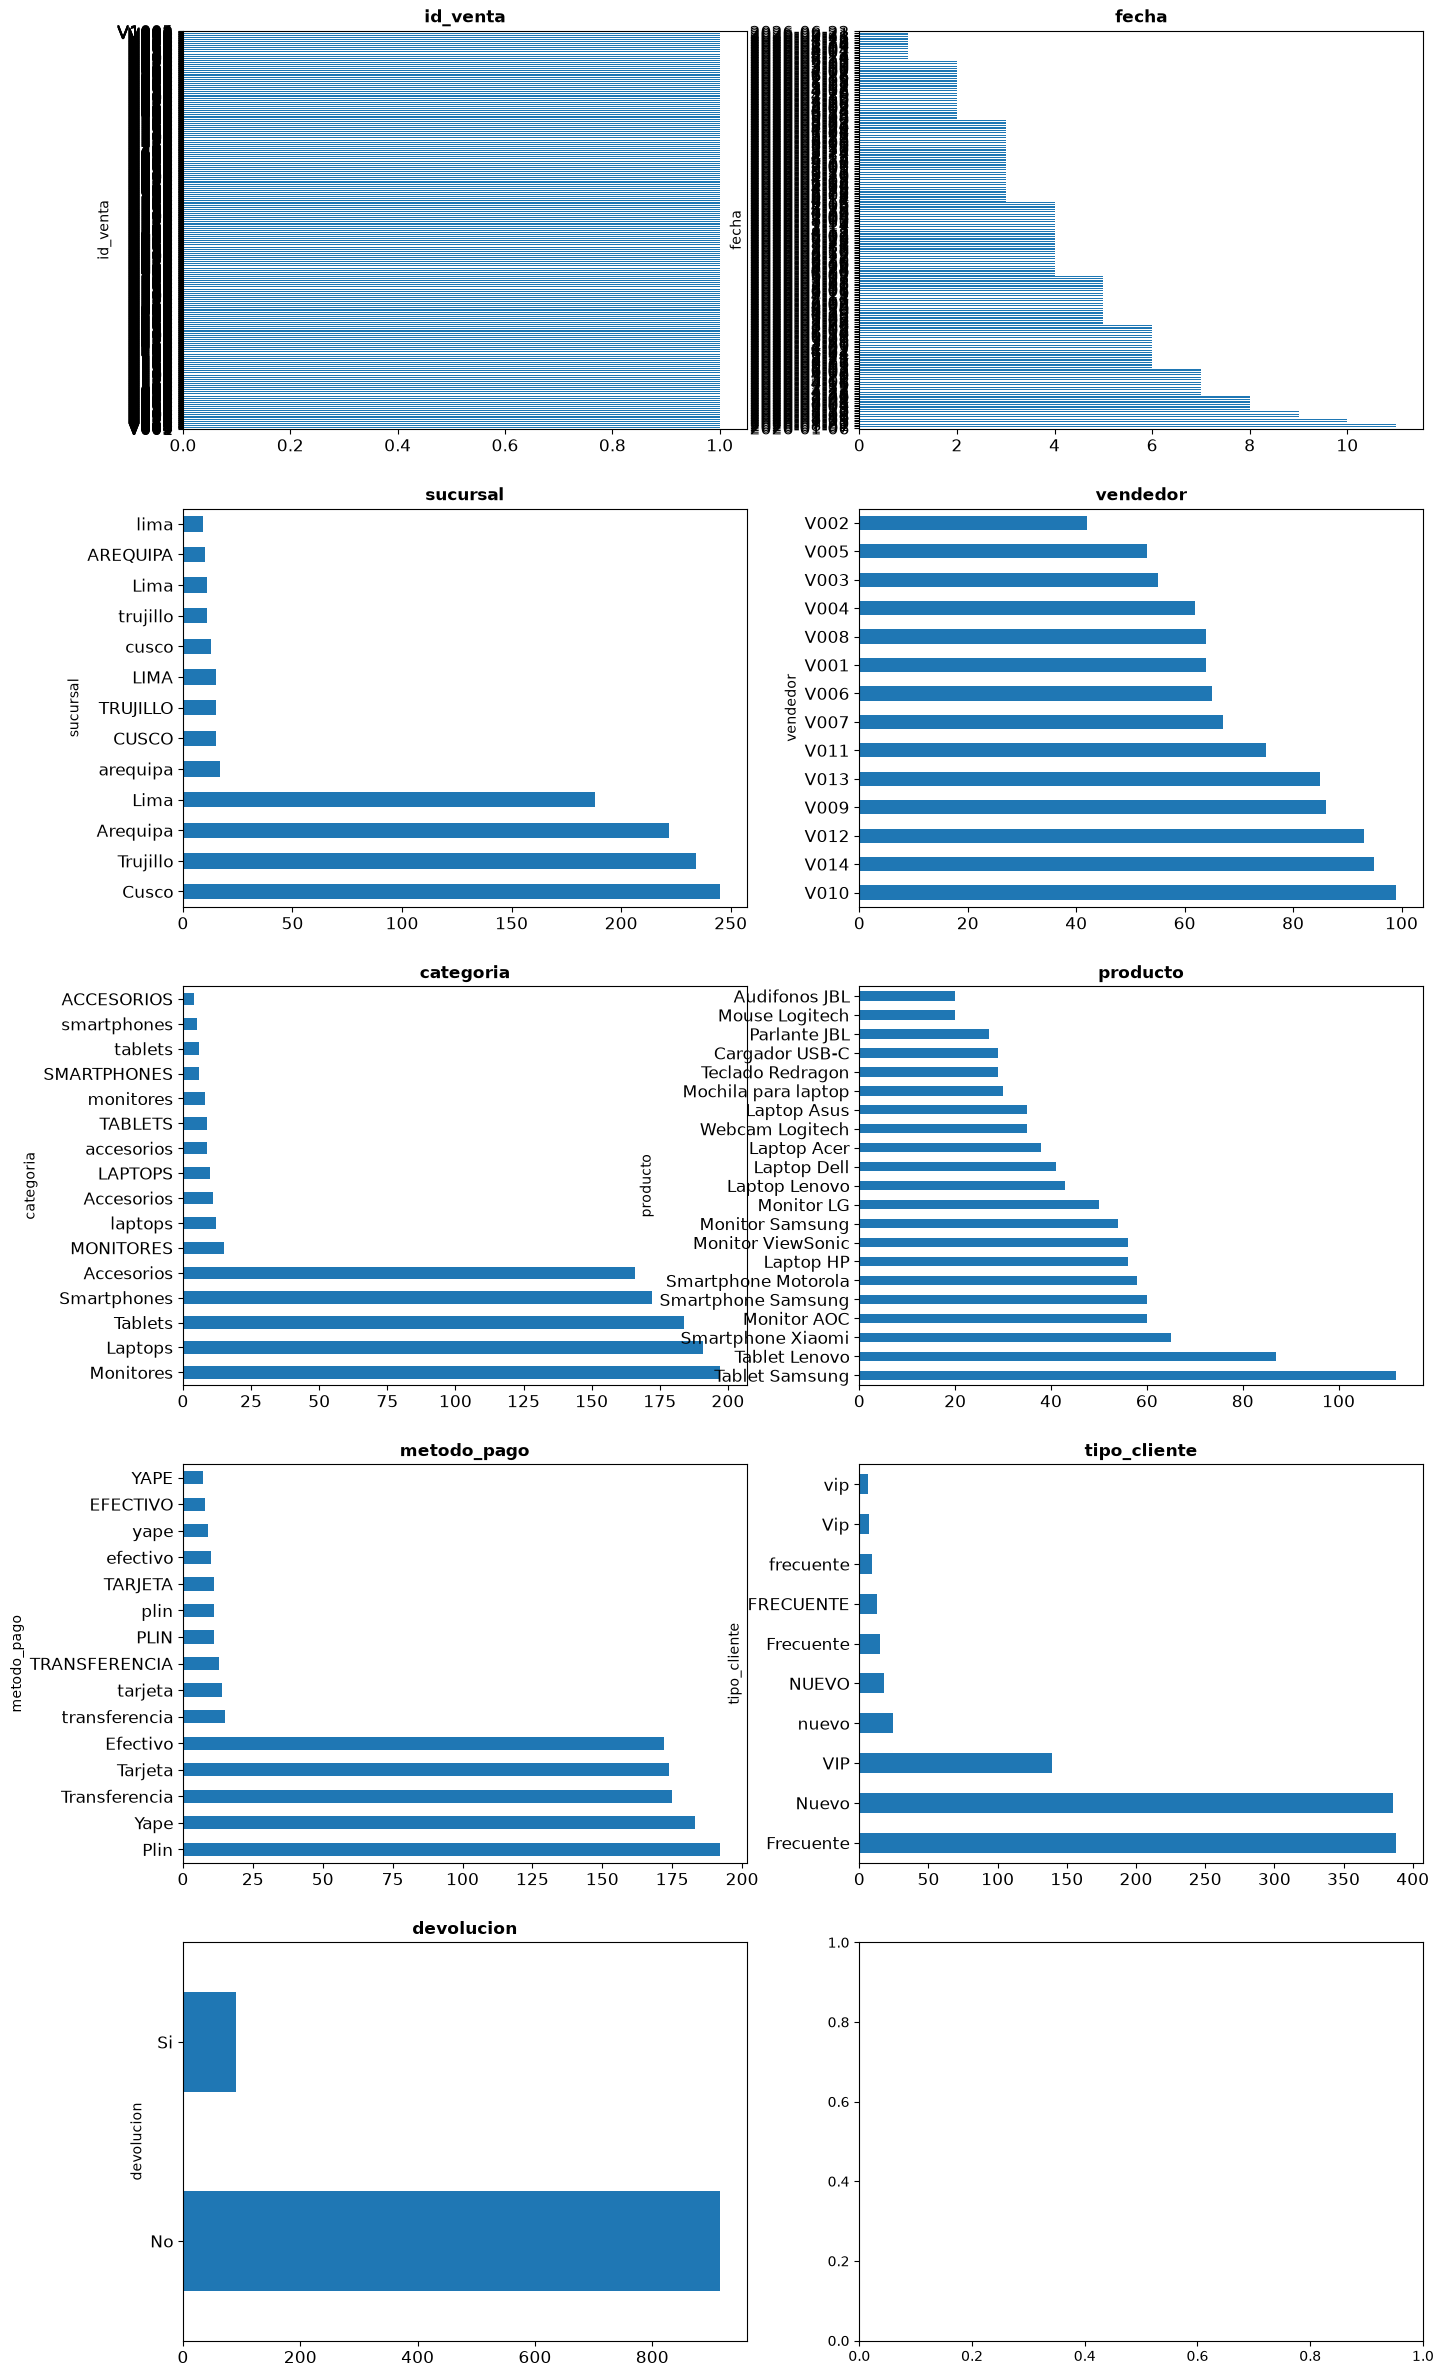

In [27]:
# 8. Mostrar graficos de datos categoricos
graficos_eda_categoricos(df_ventas.select_dtypes(include=["object"]))

In [ ]:
# 9. Normalizar categorias (sucursal, categoria, metodo_pago y tipo_cliente) convirtiendo a mayusculas y eliminando espacios en blanco
df_ventas["sucursal"] = df_ventas["sucursal"].str.upper().str.strip()
df_ventas["categoria"] = df_ventas["categoria"].str.upper().str.strip()
df_ventas["metodo_pago"] = df_ventas["metodo_pago"].str.upper().str.strip()
df_ventas["tipo_cliente"] = df_ventas["tipo_cliente"].str.upper().str.strip()

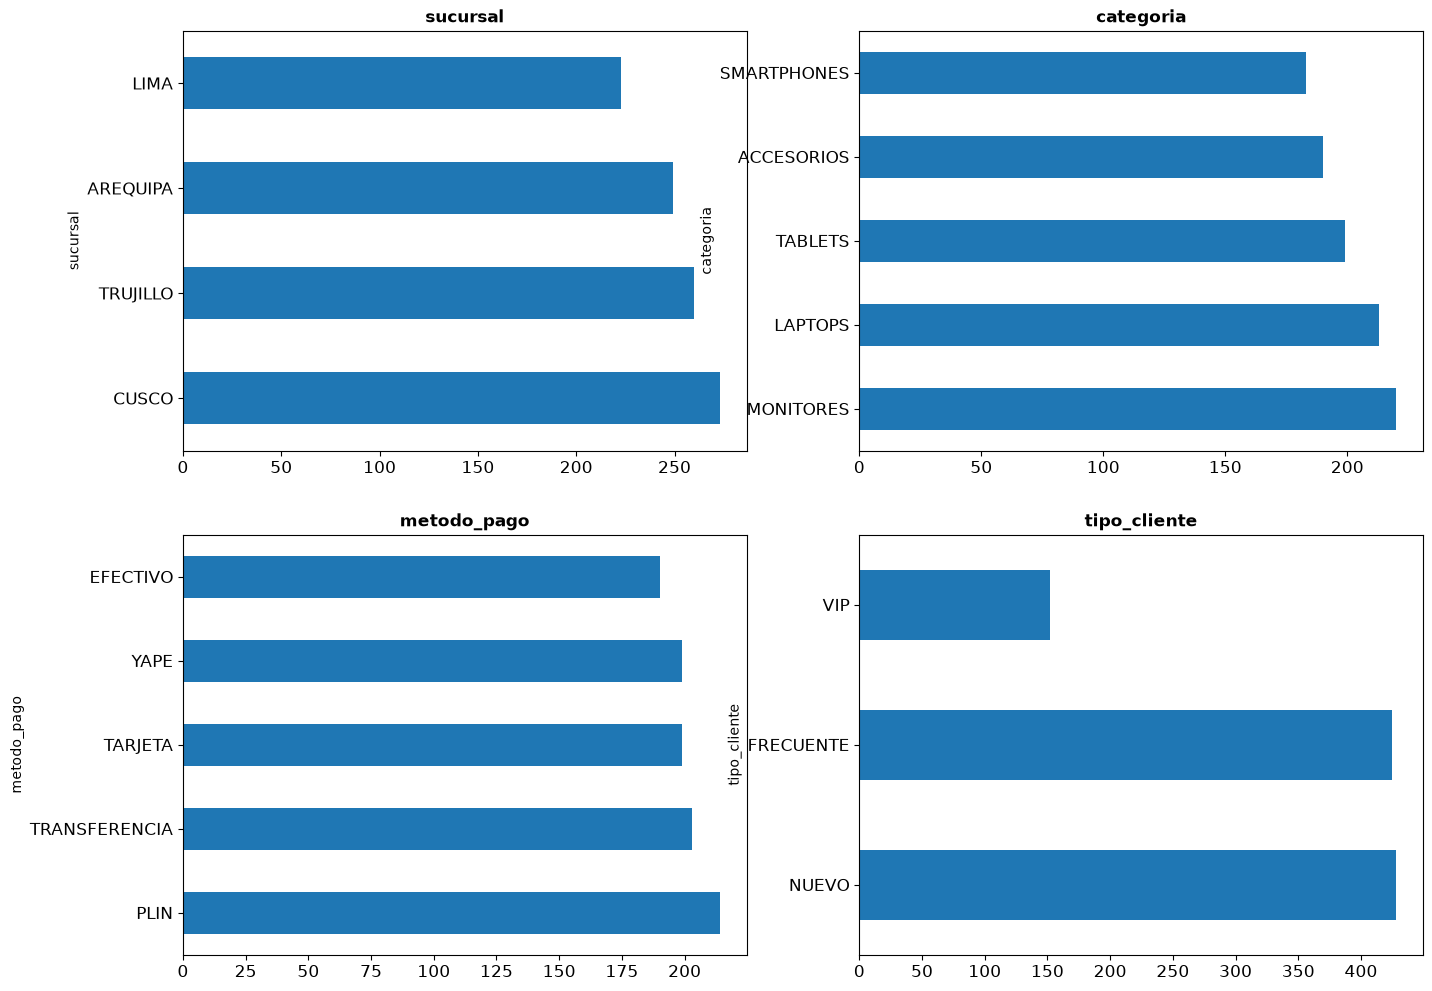

In [ ]:
# Mostramos el gráfico con las columnas normalizadas
graficos_eda_categoricos(df_ventas[["sucursal", "categoria", "metodo_pago", "tipo_cliente"]])

Conclusiones de los gráficos obtenidos:

- Cusco es la sucursal con mayor número de ventas reportado
- Los clientes VIP son los que menos compran con frecuencia
- Los métodos de pago es variable
- Laptops y monitores con la categoría de producto más vendido

In [43]:
# 10. Crear columnas adicionales para el análisis
# Crear importe de venta
df_ventas["importe_venta"] = df_ventas["cantidad"] * df_ventas["precio_unitario"]

# Crear columna de descuento
df_ventas["descuento"] = df_ventas["importe_venta"] * df_ventas["descuento_pct"] / 100

# Crear columna de importe neto
df_ventas["importe_neto"] = df_ventas["importe_venta"] - df_ventas["descuento"]

<Axes: title={'center': 'Importe Neto por Sucursal'}>

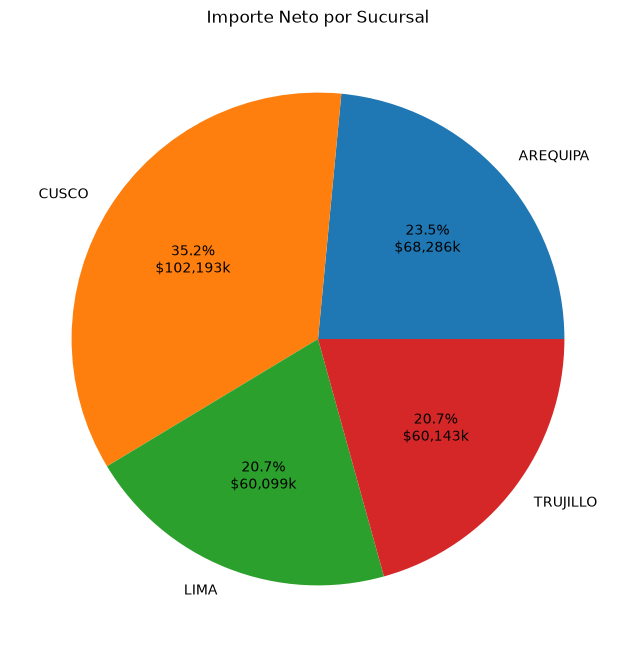

In [44]:
# 11. Calcular indicadores de venta
# Calcular el importe neto por sucursal y mostrarlo en un gráfico de pie (con etiqueta de porcentaje y el monto en miles)
importe_neto_por_sucursal = df_ventas.groupby("sucursal")["importe_neto"].sum()
importe_neto_por_sucursal.plot.pie(autopct=lambda p: '{:.1f}%\n${:,.0f}k'.format(p, p * importe_neto_por_sucursal.sum() / 1000), figsize=(8, 8), title="Importe Neto por Sucursal")

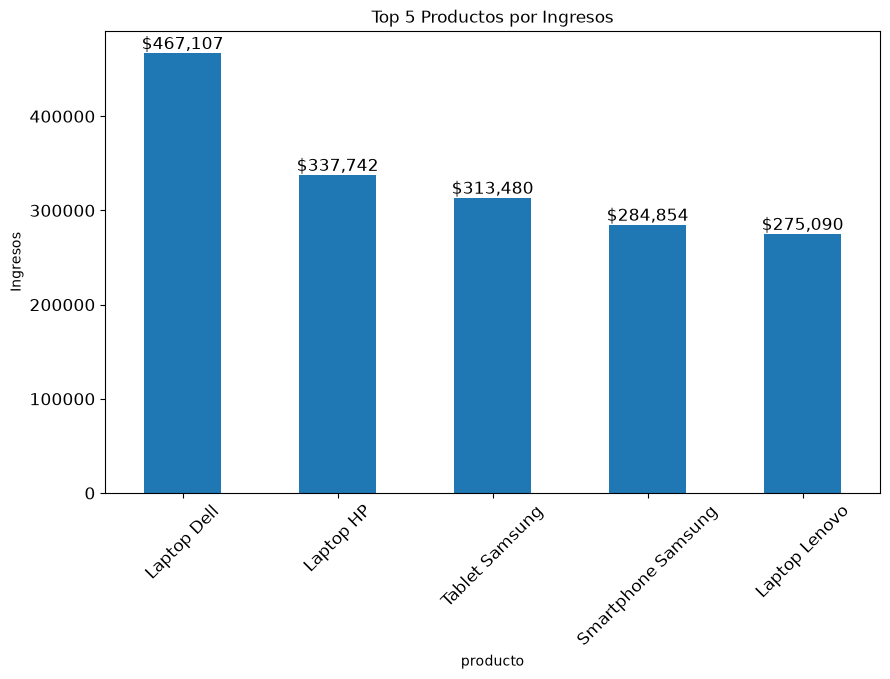

In [48]:
# Mostrar el top 5 de productos que generan mayores ingresos (mostrar monto en el grafico de barras)
top_5_productos = df_ventas.groupby("producto")["importe_neto"].sum().nlargest(5)
top_5_productos.plot.bar(figsize=(10, 6), title="Top 5 Productos por Ingresos", ylabel="Ingresos", rot=45, legend=False, fontsize=12)
for index, value in enumerate(top_5_productos):
    plt.text(index, value, f"${value:,.0f}", ha='center', va='bottom', fontsize=12)


<Axes: title={'center': 'Ventas con y sin Descuento por Sucursal'}, xlabel='sucursal', ylabel='Cantidad de Ventas'>

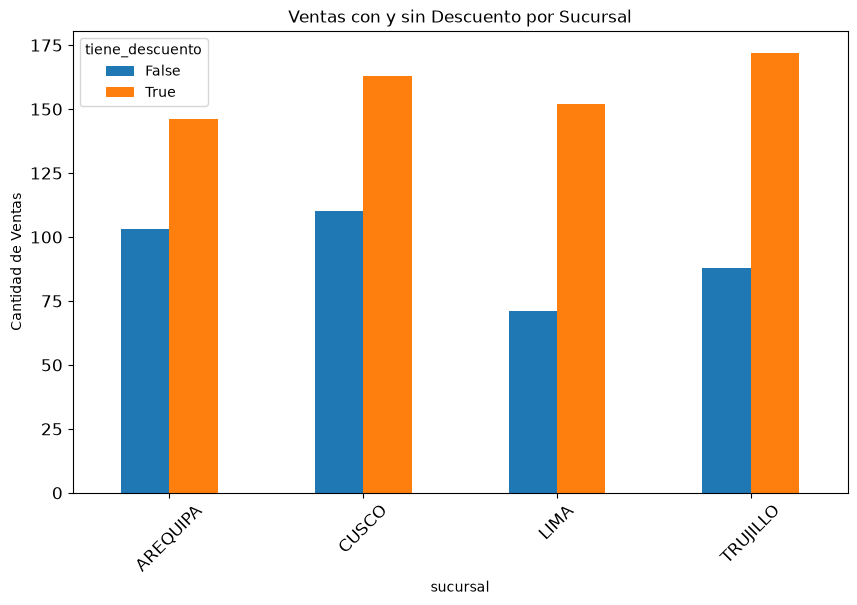

In [51]:
# Mostrar la cantidad de ventas con descuento y sin descuento por sucursal en una grafico de barras (con series)
df_ventas["tiene_descuento"] = df_ventas["descuento"] > 0

ventas_con_y_sin_descuento = df_ventas.groupby(["sucursal", "tiene_descuento"])["importe_neto"].count().unstack()
ventas_con_y_sin_descuento.plot.bar(figsize=(10, 6), title="Ventas con y sin Descuento por Sucursal", ylabel="Cantidad de Ventas", rot=45, fontsize=12)